# Estimation of stopping powers in liquid scintillator

In [1]:
pip install TDCRPy==2.16.10

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

/usr/local/python/3.12.1/lib/python3.12/site-packages/tdcrpy/TDCR_model_lib.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Stopping power at a given energy

In [3]:
density = 0.96 # in g/cm3
energy = 100 # keV
result_alpha = td.TDCR_model_lib.stoppingpowerA(energy,rho=density)
result_electron = td.TDCR_model_lib.stoppingpower(energy*1e3,rho=density)
print(f"dE/dx = {result_alpha:.7g} keV/cm for alpha particles" )
print(f"dE/dx = {result_electron*1e3:.4g} keV/cm for electrons" )

dE/dx = 1461120 keV/cm for alpha particles
dE/dx = 3421 keV/cm for electrons


## Plot stopping power curves

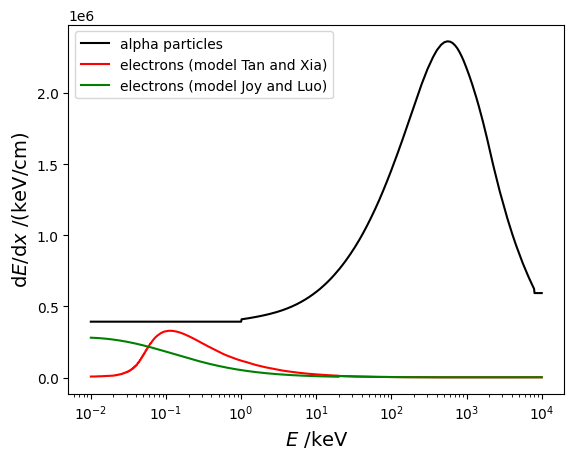

In [4]:
energy_vec = np.logspace(-2,4,1000) # in keV
w_a, w_e_tan, w_e_joy = [], [], []
for e in energy_vec:
        w_a.append(td.TDCR_model_lib.stoppingpowerA(e,rho=density))
        w_e_tan.append(1e3*td.TDCR_model_lib.stoppingpower(e*1e3,rho=density))
        w_e_joy.append(1e3*td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="joy_luo"))
plt.figure("Stopping power")
plt.clf()
plt.plot(energy_vec,w_a,"-k",label="alpha particles")
plt.plot(energy_vec,w_e_tan,"-r",label="electrons (model Tan and Xia)")
plt.plot(energy_vec,w_e_joy,"-g",label="electrons (model Joy and Luo)")
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'd$E$/d$x$ /(keV/cm)', fontsize=14)
plt.legend()